In [1]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lmfit.models import GaussianModel, VoigtModel, ConstantModel
from scipy.special import wofz
from pathlib import Path
from scipy.ndimage import median_filter
from scipy.signal import find_peaks

<h3 style="color: #e19edc;"> Lectura de espectros del 2018 y 2019</h3>
<h5 style="color: #e19edc;"> Los espectros del 2019 fueron tomados en las Islas Canarias</h5>

In [2]:
#Rutas Julio, Agosto y Septiembre

ruta_24_julio = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018 y 2019\2018-07-24.xlsx"
ruta_27_julio = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018 y 2019\2018-07-27.xlsx"
ruta_03_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018 y 2019\2018-08-03.xlsx"
ruta_07_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018 y 2019\2018-08-07.xlsx"
ruta_11_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018 y 2019\2018-08-11.xlsx"
ruta_16_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018 y 2019\2018-08-16.xlsx"
ruta_23_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018 y 2019\2018-08-23.xlsx"
ruta_29_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018 y 2019\2018-08-29.xlsx"
ruta_11_septiembre = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018 y 2019\2018-09-11.xlsx"
ruta_05_agosto_19 = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018 y 2019\2019-08-05.xlsx"

In [3]:
#Datos de Julio, Agosto y Septiembre

antares_24_julio = pd.read_excel(ruta_24_julio, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_27_julio = pd.read_excel(ruta_27_julio, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_03_agosto = pd.read_excel(ruta_03_agosto, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_07_agosto = pd.read_excel(ruta_07_agosto, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_11_agosto = pd.read_excel(ruta_11_agosto, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_16_agosto = pd.read_excel(ruta_16_agosto, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_23_agosto = pd.read_excel(ruta_23_agosto, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_29_agosto = pd.read_excel(ruta_29_agosto, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_11_septiembre = pd.read_excel(ruta_11_septiembre, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_05_agosto_19 = pd.read_excel(ruta_05_agosto_19, sheet_name = "Sheet1", usecols = [0,1],header = None, names = ["Longitud onda", "Flujo"])

In [4]:
espectros = {
    "antares_24_julio": antares_24_julio,
    "antares_27_julio": antares_27_julio,
    "antares_03_agosto": antares_03_agosto,
    "antares_07_agosto": antares_07_agosto,
    "antares_11_agosto": antares_11_agosto,
    "antares_16_agosto": antares_16_agosto,
    "antares_23_agosto": antares_23_agosto,
    "antares_29_agosto": antares_29_agosto,
    "antares_11_septiembre": antares_11_septiembre,
    "antares_05_agosto_19": antares_05_agosto_19
}

<h4 style="color: #e19edc;"> Parámetros de la normalización con el método Sigma - Clipping</h4>

In [5]:
guardar_graficos = True   
carpeta_graficos = "./Graficas 2018 y 2019/Espectros_normalizados"  
 
col_longitud_onda = "Longitud onda"
col_flujo = "Flujo"
 
grado_polinomio= 2     
N_iteraciones = 10
sigma_corte = 2.0

<h5 style="color: #e19edc;"> Modelo</h5>

In [7]:
def ajustar_continuo(longitud_onda, flujo, grado, n_iter, sigma):

    longitud_onda = np.asarray(longitud_onda, dtype=float)
    flujo = np.asarray(flujo, dtype=float)
 
    mascara = np.ones_like(flujo, dtype=bool)
 
    for _ in range(n_iter):
        coef = np.polyfit(longitud_onda[mascara], flujo[mascara], deg=grado)
        continuo_iter = np.polyval(coef, longitud_onda)
 
        residuo = flujo - continuo_iter
        
        mediana = np.median(residuo[mascara])
        mad = np.median(np.abs(residuo[mascara] - mediana))
        mad_std = mad * 1.4826

        umbral_superior = mediana + sigma * mad_std
        umbral_inferior = mediana - sigma * mad_std
        nueva_mascara = (residuo > umbral_inferior) & (residuo < umbral_superior)
 
        if nueva_mascara.sum() < grado + 2:
            break

        if np.array_equal(nueva_mascara, mascara):
            break
 
        mascara = nueva_mascara
 
    coef_final = np.polyfit(longitud_onda[mascara], flujo[mascara], deg=grado)
    continuo = np.polyval(coef_final, longitud_onda)
 
    return continuo, mascara


<h5 style="color: #e19edc;"> Verificación del modelo con gráficos</h5>


Procesando: antares_24_julio
  Puntos totales: 203
  Puntos excluidos: 51
  -> Gráfico guardado: Graficas 2018 y 2019\Espectros_normalizados\antares_24_julio_control.png


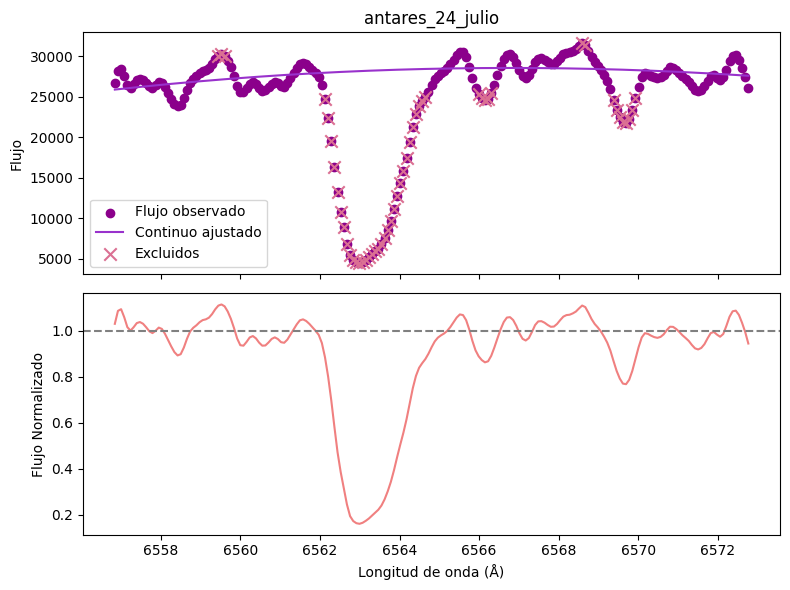


Procesando: antares_27_julio
  Puntos totales: 158
  Puntos excluidos: 68
  -> Gráfico guardado: Graficas 2018 y 2019\Espectros_normalizados\antares_27_julio_control.png


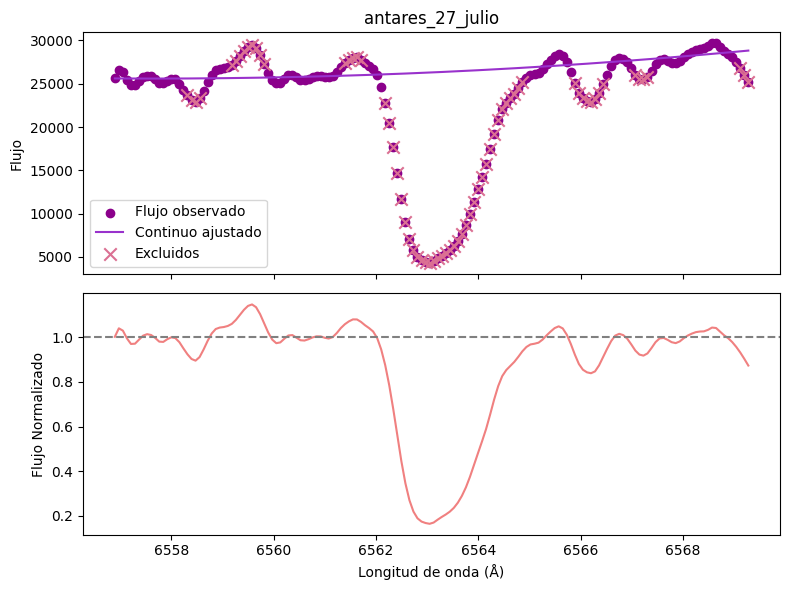


Procesando: antares_03_agosto
  Puntos totales: 161
  Puntos excluidos: 44
  -> Gráfico guardado: Graficas 2018 y 2019\Espectros_normalizados\antares_03_agosto_control.png


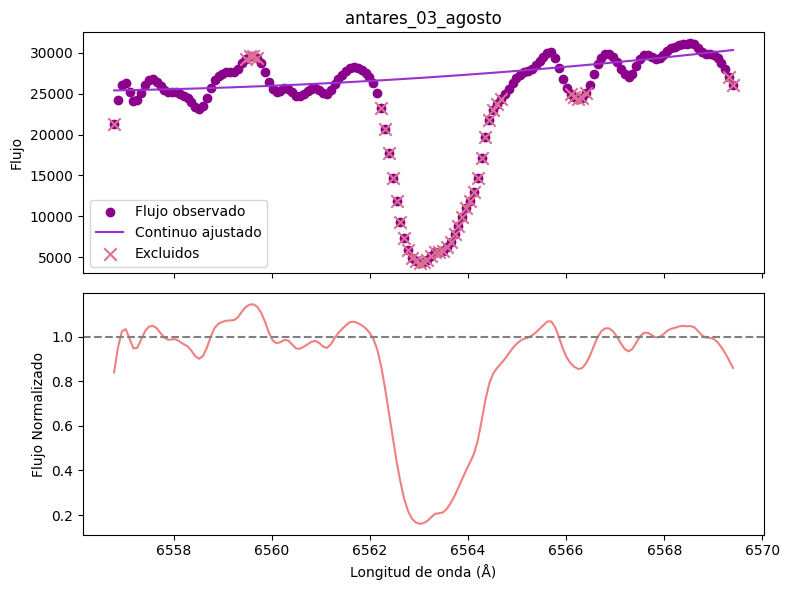


Procesando: antares_07_agosto
  Puntos totales: 162
  Puntos excluidos: 54
  -> Gráfico guardado: Graficas 2018 y 2019\Espectros_normalizados\antares_07_agosto_control.png


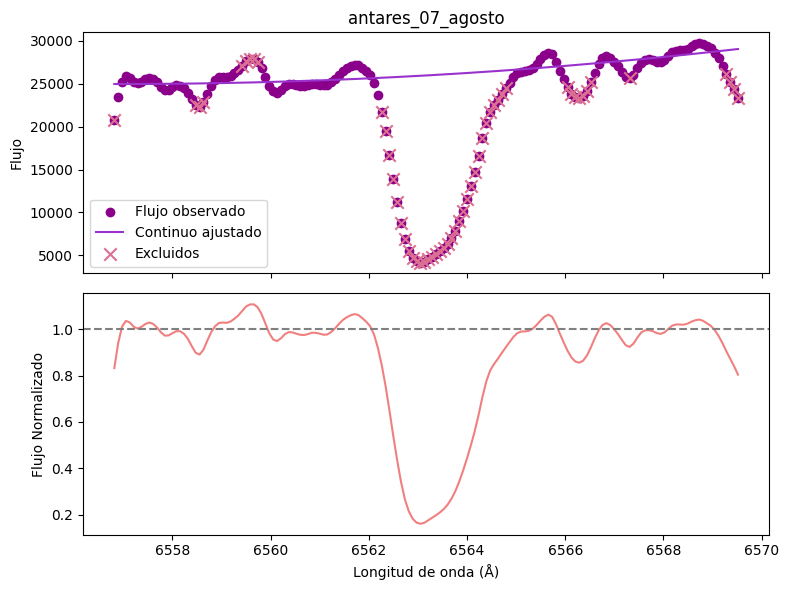


Procesando: antares_11_agosto
  Puntos totales: 163
  Puntos excluidos: 62
  -> Gráfico guardado: Graficas 2018 y 2019\Espectros_normalizados\antares_11_agosto_control.png


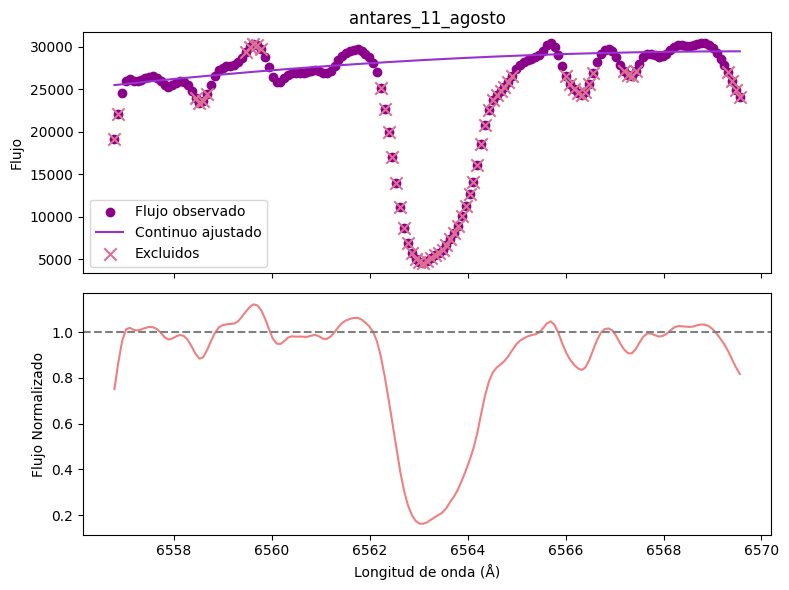


Procesando: antares_16_agosto
  Puntos totales: 163
  Puntos excluidos: 61
  -> Gráfico guardado: Graficas 2018 y 2019\Espectros_normalizados\antares_16_agosto_control.png


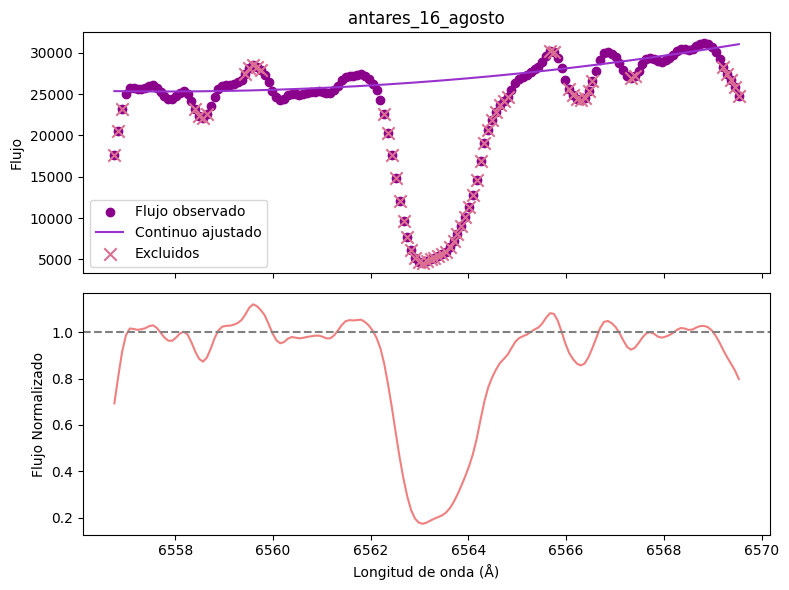


Procesando: antares_23_agosto
  Puntos totales: 162
  Puntos excluidos: 52
  -> Gráfico guardado: Graficas 2018 y 2019\Espectros_normalizados\antares_23_agosto_control.png


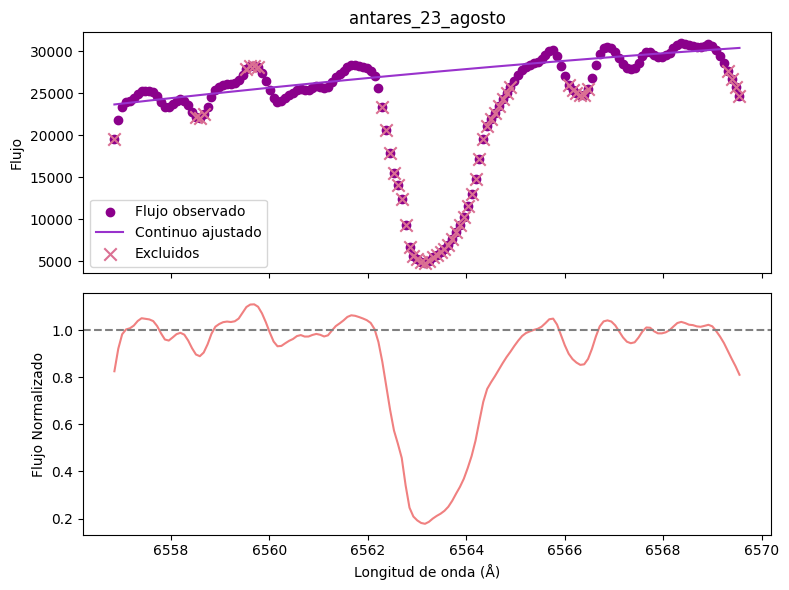


Procesando: antares_29_agosto
  Puntos totales: 206
  Puntos excluidos: 83
  -> Gráfico guardado: Graficas 2018 y 2019\Espectros_normalizados\antares_29_agosto_control.png


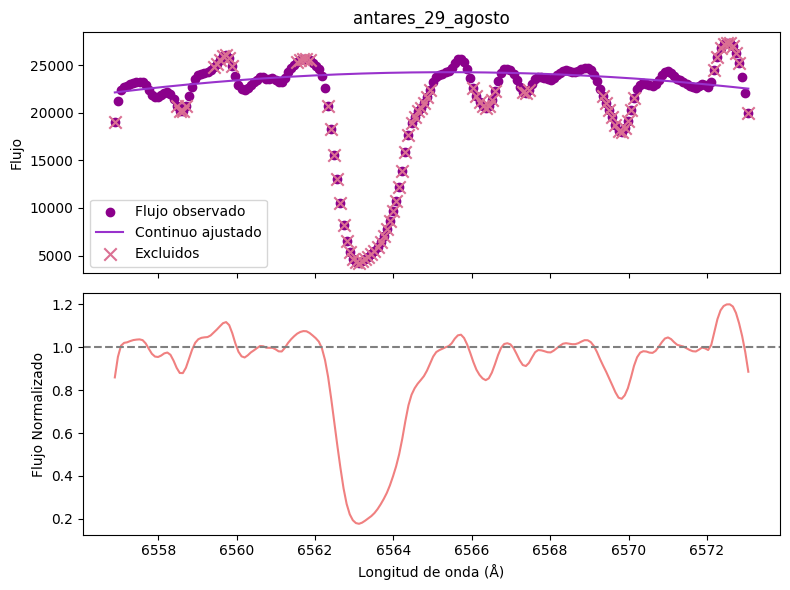


Procesando: antares_11_septiembre
  Puntos totales: 208
  Puntos excluidos: 64
  -> Gráfico guardado: Graficas 2018 y 2019\Espectros_normalizados\antares_11_septiembre_control.png


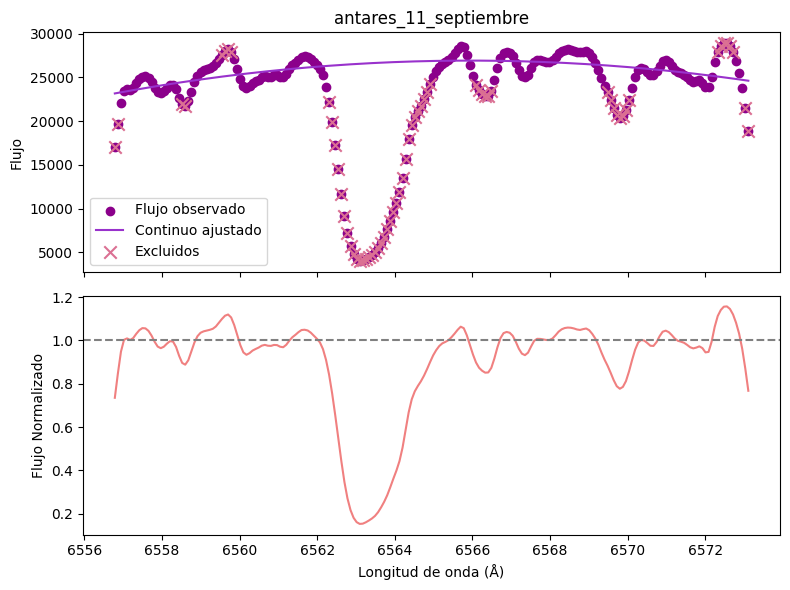


Procesando: antares_05_agosto_19
  Puntos totales: 290
  Puntos excluidos: 147
  -> Gráfico guardado: Graficas 2018 y 2019\Espectros_normalizados\antares_05_agosto_19_control.png


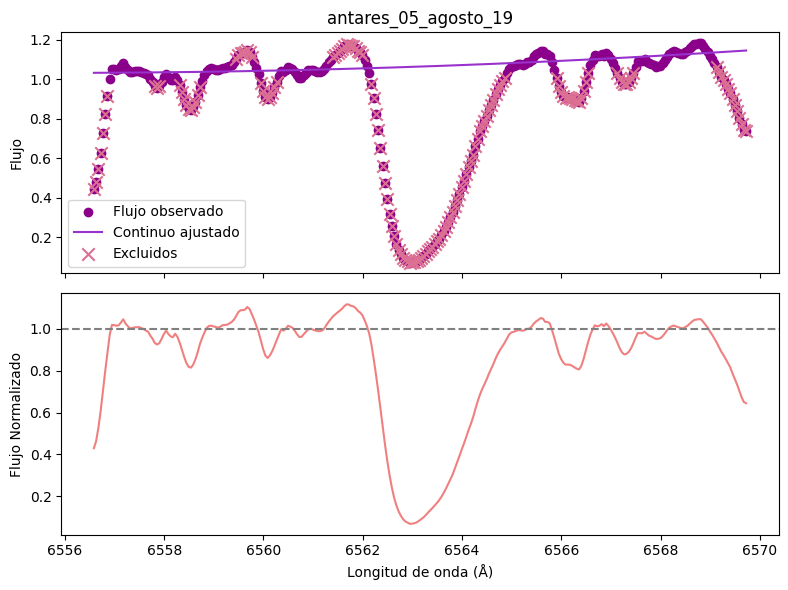


Proceso completo.


In [18]:
if guardar_graficos:
    Path(carpeta_graficos).mkdir(exist_ok=True)
 
for nombre, df in espectros.items():
    print(f"\nProcesando: {nombre}")
 
    longitud_onda = df[col_longitud_onda].values
    flujo = df[col_flujo].values
 
    continuo, mascara_continuo = ajustar_continuo(longitud_onda, flujo, grado_polinomio, N_iteraciones, sigma_corte)

    df["Continuo ajustado"] = continuo
    df["Flujo Normalizado"] = flujo / continuo
    df["Usado en ajuste"] = mascara_continuo

    print(f"  Puntos totales: {len(mascara_continuo)}")
    print(f"  Puntos excluidos: {(~mascara_continuo).sum()}")

    mascara_bool = np.asarray(mascara_continuo, dtype=bool)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
 
    ax1.scatter(longitud_onda, flujo, color = "darkmagenta", label="Flujo observado")
    ax1.plot(longitud_onda, continuo, color ="darkorchid", label="Continuo ajustado")
    ax1.scatter(longitud_onda[~mascara_bool], flujo[~mascara_bool], color = "palevioletred",marker = "x", label="Excluidos", s = 80)
    ax1.set_ylabel("Flujo")
    ax1.legend()
    ax1.set_title(nombre)
 
    ax2.plot(longitud_onda, df["Flujo Normalizado"], color ="lightcoral")
    ax2.axhline(1.0, color="gray", linestyle="--")
    ax2.set_ylabel("Flujo Normalizado")
    ax2.set_xlabel("Longitud de onda (Å)")
 
    plt.tight_layout()
 
    if guardar_graficos:
        fig_path = Path(carpeta_graficos) / f"{nombre}_control.png"
        plt.savefig(fig_path, dpi=120)
        print(f"  -> Gráfico guardado: {fig_path}")
 
    plt.show()
    plt.close(fig)
 
print("\nProceso completo.")

In [19]:
metadatos = {
    "antares_24_julio": {
        "fecha": "Julio 24-2018",
        "datos": antares_24_julio,
        "centro_aprox": 6562.994,
        "Velocidad Hα": 19.4,
        "Incertidumbre v Hα": 0.7,
        "Velocidad Sector naranja": 19.76,
        "Incertidumbre v Sector naranja": 0.05,
    },
    "antares_27_julio": {
        "fecha": "Julio 27-2018",
        "datos": antares_27_julio,
        "centro_aprox": 6563.045,
        "Velocidad Hα": 20.2,
        "Incertidumbre v Hα": 0.8,
    },
    "antares_03_agosto": {
        "fecha": "Agosto 03-2018",
        "datos": antares_03_agosto,
        "centro_aprox": 6563.015,
        "Velocidad Hα": 23,
        "Incertidumbre v Hα": 0.9,
        "Velocidad Sector naranja": 23.5,
        "Incertidumbre v Sector naranja": 0.03,
    },
    "antares_07_agosto": {
        "fecha": "Agosto 07-2018",
        "datos": antares_07_agosto,
        "centro_aprox": 6563.05116,
        "Velocidad Hα": 23.9,
        "Incertidumbre v Hα": 0.5,
        "Velocidad Sector naranja": 24.1,
        "Incertidumbre v Sector naranja": 0.04,
    },
    "antares_11_agosto": {
        "fecha": "Agosto 11-2018",
        "datos": antares_11_agosto,
        "centro_aprox": 6563.091,
        "Velocidad Hα": 24.9,
        "Incertidumbre v Hα": 0.7,
    },
    "antares_16_agosto": {
        "fecha": "Agosto 16-2018",
        "datos": antares_16_agosto,
        "centro_aprox": 6563.067,
        "Velocidad Hα": 25.1,
        "Incertidumbre v Hα": 0.4,
        "Velocidad Sector naranja": 25.8,
        "Incertidumbre v Sector naranja": 0.06,
    },
    "antares_23_agosto": {
        "fecha": "Agosto 23-2018",
        "datos": antares_23_agosto,
        "centro_aprox": 6563.164,
        "Velocidad Hα": 26,
        "Incertidumbre v Hα": 0.5,
        "Velocidad Sector naranja": 26.18,
        "Incertidumbre v Sector naranja": 0.11,
    },
    "antares_29_agosto": {
        "fecha": "Agosto 29-2018",
        "datos": antares_29_agosto,
        "centro_aprox": 6563.131,
        "Velocidad Hα": 26.3,
        "Incertidumbre v Hα": 0.4,
        "Velocidad Sector naranja": 27.09,
        "Incertidumbre v Sector naranja": 0.15,
    },
    "antares_11_septiembre": {
        "fecha": "Septiembre 11-2018",
        "datos": antares_11_septiembre,
        "centro_aprox": 6563.095,
        "Velocidad Hα": 26,
        "Incertidumbre v Hα": 0.5,
        "Velocidad Sector naranja": 26.75,
        "Incertidumbre v Sector naranja": 0.09,
    },
    "antares_05_agosto_19": {
        "fecha": "Agosto 05-2019",
        "datos": antares_05_agosto_19,
        "centro_aprox": 6562.948,
        "Velocidad Hα": 23,
        "Incertidumbre v Hα": 0.5,
        },
}

<h3 style="color: #e19edc;"> Obtención del perfil de absorción y emisión de la línea H<sub>&alpha;</sub></h3>

<h4 style="color: #e19edc;"> Teniendo en cuenta las posibles mezclas con las líneas de absorción</h4>

<h5 style="color: #e19edc;"> Funciones complementarias</h5>

In [20]:
c_kms_s = 299792.458

def efecto_doppler(longitud_lab, velocidad_kms):
    return longitud_lab * (1 + velocidad_kms / c_kms_s)

def velocidad_desde_doppler(longitud_lab, longitud_obs):
    return c_kms_s * (longitud_obs / longitud_lab - 1)

def profundidad_interpolada(teff, t_ref=(3500, 4250), prof_ref=(0.55, 0.63)):
    return float(np.interp(teff, t_ref, prof_ref))

def pico_unitario_voigt(sigma, gamma):
    z = 1j * gamma / (sigma * np.sqrt(2))
    return wofz(z).real / (sigma * np.sqrt(2 * np.pi))

In [11]:
def estimar_continuo_por_planitud(longitud_onda, flujo, rango_flujo,max_variacion=0.015, ventana_vecinos=2,
                                    grado_ajuste=1, min_puntos=5):

    serie_flujo = pd.Series(flujo)

    ventana_total = 2 * ventana_vecinos + 1
    variacion_local = serie_flujo.rolling(window=ventana_total, center=True).std()

    mascara_rango = (flujo >= rango_flujo[0]) & (flujo <= rango_flujo[1])
    mascara_plano = (variacion_local < max_variacion).to_numpy()

    mascara = mascara_rango & mascara_plano

    x_sel = longitud_onda[mascara]
    y_sel = flujo[mascara]

    if x_sel.size < min_puntos:
        raise ValueError(
            f"Solo se encontraron {x_sel.size} puntos de continuo (mínimo {min_puntos}). "
            f"Ajustá 'rango_flujo' o 'max_variacion'. Rango de flujo real en este espectro: "
            f"[{flujo.min():.3f}, {flujo.max():.3f}]"
        )

    orden = np.argsort(x_sel)
    x_sel, y_sel = x_sel[orden], y_sel[orden]

    coef = np.polyfit(x_sel, y_sel, deg=grado_ajuste)
    continuo_func = np.poly1d(coef)

    return continuo_func, x_sel, y_sel

In [17]:
# Configuración manual de vecinos por prueba específica
vecinos_manuales = {
    "Julio 24-2018": {"v_g1": 4},
    "Julio 27-2018": {"v_g1": 4},
    "Agosto 03-2018": {"v_g1": 3},
    "Agosto 07-2018": {"v_g1": 3},
    "Agosto 11-2018": {"v_g1": 3},
    "Agosto 16-2018": {"v_g1": 3},
    "Agosto 23-2018": {"v_g1": 3},
    "Agosto 29-2018": {"v_g1": 3},
    "Septiembre 11-2018": {"v_g1": 3},
    "Agosto 05-2019": {"v_g1": 3},
    }

filas_comparativa = []

for archivo in metadatos.values():
    fecha = archivo["fecha"]
    df = archivo["datos"]
    centro_aprox = archivo["centro_aprox"]

    longitud_onda = df["Longitud onda"].values
    flujo = df["Flujo Normalizado"].values

    # Extraer ventana manual
    cfg = vecinos_manuales.get(fecha, {"v_g1": 2})
    v_g1 = cfg["v_g1"]

    # Grado 1
    try:
        cont_func1, x_sel1, y_sel1 = estimar_continuo_por_planitud(
            longitud_onda, flujo, rango_flujo=(0.8, 1), max_variacion=0.015,
            ventana_vecinos=v_g1, grado_ajuste=1
        )
        res1 = y_sel1 - cont_func1(x_sel1)
        c_centro1 = round(float(cont_func1(centro_aprox)), 4)
        std1 = round(float(np.std(res1)), 5)
    except Exception as e:
        cont_func1 = None
        c_centro1, std1 = None, f"Falló: {e}"

    # Tabla
    filas_comparativa.append({
        "Espectro / Fecha": fecha,
        "Vecinos (G1)": v_g1,
        "Continuo Centro (G1)": c_centro1,
        "Residuo std (G1)": std1
    })


    fig, ax = plt.subplots(figsize=(7, 4))

    ax.plot(longitud_onda, flujo, color="gray", alpha=0.5, label="Espectro observado", zorder=1)
    if cont_func1 is not None:
        ax.scatter(x_sel1, y_sel1, color="darkmagenta", s=18, label="Puntos continuo sel.", zorder=2)
        ax.plot(longitud_onda, cont_func1(longitud_onda), color="crimson", lw=2, label="Ajuste Pol. Grado 1", zorder=3)
        ax.axhline(c_centro1, color="gold", linestyle="--", lw=1.5, label=f"Nivel cont. centro: {c_centro1:.4f}", zorder=3)
        ax.scatter([centro_aprox], [c_centro1], color="yellow", edgecolor="black", s=70, zorder=4)

    ax.set_title(f"{fecha} - Grado 1 (Vecinos={v_g1})", fontsize=11, fontweight="bold")
    ax.set_xlabel(r"Longitud de onda [$\mathrm{\AA}$]")
    ax.set_ylabel("Flujo normalizado")
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

# Tabla en pantalla con DataFrame
tabla_comparativa_manual = pd.DataFrame(filas_comparativa)
display(tabla_comparativa_manual)

KeyError: 'Flujo Normalizado'

In [15]:
def estimar_ancho_inicial_metalica(longitud_onda, flujo, continuo_local, centro_obs, ventana=0.5, sigma_default=0.12, gamma_default=0.05):

    mask = np.abs(longitud_onda - centro_obs) < ventana
    if mask.sum() < 4:
        return sigma_default, gamma_default

    x_local = longitud_onda[mask]
    y_local = flujo[mask]


    nivel_min = np.percentile(y_local, 2)
    prof_local = continuo_local - nivel_min
    if prof_local <= 0:
        return sigma_default, gamma_default

    nivel_media_altura = continuo_local - prof_local / 2

    por_debajo = y_local < nivel_media_altura
    if por_debajo.sum() < 2:
        return sigma_default, gamma_default

    x_cruce = x_local[por_debajo]
    fwhm_est = x_cruce.max() - x_cruce.min()

    if fwhm_est <= 0:
        return sigma_default, gamma_default

    sigma_inicial = max(0.02, fwhm_est / 2.355)
    gamma_inicial = max(0.0, fwhm_est * 0.15)

    return sigma_inicial, gamma_inicial

<h5 style="color: #e19edc;"> Modelamiento </h5>

In [16]:
#MODELO DE AJUSTE

def construccion_del_modelo(lineas_metalicas=None):
    continuo = ConstantModel(prefix="cont_")
    em_azul = VoigtModel(prefix="em_azul_")
    valle_abs = VoigtModel(prefix="valle_abs_")
    modelo = continuo + em_azul + valle_abs

    if lineas_metalicas:
        for linea in lineas_metalicas:
            modelo += VoigtModel(prefix=f"{linea['nombre']}_")

    return modelo

def encontrar_parametros(modelo, longitud_onda, flujo, centro_aprox, lineas_metalicas, teff=3660):
    p = modelo.make_params()
    p._asteval.symtable['pico_unitario_voigt'] = pico_unitario_voigt

    # Continuo
    continuo_local = estimar_continuo_local(longitud_onda, flujo, centro_aprox)
    p["cont_c"].set(value=continuo_local, min=continuo_local - 0.05, max=continuo_local + 0.05)

    flujo_suave = median_filter(flujo, size = 5)

    # Emisión Azul

    izquierda = (longitud_onda < (centro_aprox - 0.25)) & (longitud_onda > (centro_aprox - 2.5))

    if np.any(izquierda):
        x_izq = longitud_onda[izquierda]
        y_izq = flujo_suave[izquierda]

        picos, props = find_peaks(y_izq, prominence=0.01)

        if len(picos) > 0:
            idx_mejor = picos[np.argmax(props["prominences"])]
            c_azul_inicio = x_izq[idx_mejor]
            amp_azul_inicio = max(0.05, flujo[izquierda][idx_mejor] - continuo_local)
        else:
            i_azul = np.argmax(y_izq)
            c_azul_inicio = x_izq[i_azul]
            amp_azul_inicio = max(0.05, flujo[izquierda][i_azul] - continuo_local)
    else:
        c_azul_inicio = centro_aprox - 0.8
        amp_azul_inicio = 0.2

    p["em_azul_center"].set(value = c_azul_inicio, min = centro_aprox - 2.8, max = centro_aprox - 0.15)
    p["em_azul_amplitude"].set(value = amp_azul_inicio * 0.5, min = 0, max = amp_azul_inicio * 5.0)
    p["em_azul_sigma"].set(value = 0.30, min = 0.05, max = 1.2)
    p["em_azul_gamma"].set(value = 0.15, min = 0.0, max = 1.0, vary=True)

    # Absorción central (Halpha)

    ventana_centro = np.abs(longitud_onda - centro_aprox) < 1.8

    if np.any(ventana_centro):
        idx_local = np.argmin(flujo_suave[ventana_centro])
        c_abs_inicio = longitud_onda[ventana_centro][idx_local]
    else:
        c_abs_inicio = centro_aprox

    i_min = np.argmin(np.abs(longitud_onda - c_abs_inicio))

    p["valle_abs_center"].set(value = c_abs_inicio, min = centro_aprox - 1.0, max = centro_aprox + 1.0)

    prof_abs_est = max(0.1, continuo_local - flujo[i_min])
    amp_abs_inicio = -prof_abs_est * 0.8
    p["valle_abs_amplitude"].set(value = amp_abs_inicio, max = 0)
    p["valle_abs_sigma"].set(value = 0.25, min = 0.05, max = 1.0)
    p["valle_abs_gamma"].set(value = 0.15, min = 0, max = 0.8, vary=True)

    # Líneas Metálicas
    if lineas_metalicas:
        for linea in lineas_metalicas:
            pref = f"{linea['nombre']}_"
            c0_lab = linea["centro"]

            v = linea.get("velocidad", 0.0)
            c0_obs = efecto_doppler(c0_lab, v)
            margen_v = linea.get("incertidumbre_v", 3.0)
            margen_aa = c0_lab * margen_v / c_kms_s
            p[f"{pref}center"].set(value=c0_obs, min=c0_obs - margen_aa, max=c0_obs + margen_aa)

            # Estimación robusta del ancho inicial
            sigma0_dato, gamma0_dato = estimar_ancho_inicial_metalica(longitud_onda, flujo, continuo_local, c0_obs)

            sigma0 = linea.get("sigma_inicial", sigma0_dato)
            gamma0 = linea.get("gamma_inicial", gamma0_dato)

            # Los anchos se fijan dentro de un rango del valor inicial estimado.
            sigma_margen = 0.05
            gamma_margen = 0.05
            p[f"{pref}sigma"].set(value=sigma0, min=max(0.02, sigma0 - sigma_margen), max=min(0.4, sigma0 + sigma_margen))
            p[f"{pref}gamma"].set(value=gamma0, min=max(0.0, gamma0 - gamma_margen), max=min(0.3, gamma0 + gamma_margen), vary=True)

            prof = linea.get("profundidad")
            if prof is None:
                prof = profundidad_interpolada(teff, t_ref=linea.get("t_ref", (3500, 4250)), prof_ref=linea.get("prof_ref", (0.55, 0.63)))

            p[f"{pref}amplitude"].set(expr=f"-{prof} * cont_c / pico_unitario_voigt({pref}sigma, {pref}gamma)" )

    return p

In [19]:
# DESCOMPOSICIÓN DE "PERFILES" DE Hα

def fit_y_decomposicion(datos_cercanos, centro_aprox, longitud_observada, flujo_normalizado,
                         lineas_metalicas=None, teff=3660):
    longitud_onda = datos_cercanos[longitud_observada].to_numpy()
    flujo = datos_cercanos[flujo_normalizado].to_numpy()

    modelo = construccion_del_modelo(lineas_metalicas)
    parametros = encontrar_parametros(modelo, longitud_onda, flujo, centro_aprox,
                                       lineas_metalicas, teff=teff)
    fit = modelo.fit(flujo, parametros, x=longitud_onda)

    comps = fit.eval_components(x=longitud_onda)
    continuo = comps["cont_"]

    perfil_emision = continuo + comps["em_azul_"]
    perfil_absorcion = continuo + comps["valle_abs_"]
    residuo = flujo - fit.best_fit

    return dict(longitud_onda = longitud_onda, flujo = flujo, fit = fit, comps = comps, perfil_emision = perfil_emision,
                perfil_absorcion = perfil_absorcion, residuo=residuo)

In [20]:
# VISUALIZACIÓN

def visualizacion_con_metalica(res_metal, lineas_metalicas, mes, titulo,):
    longitud_onda, flujo, fit = res_metal["longitud_onda"], res_metal["flujo"], res_metal["fit"]
    comps = res_metal["comps"]
    continuo = comps["cont_"]

    fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                              gridspec_kw={"height_ratios": [2.2, 1]})

    ax = axes[0]
    ax.scatter(longitud_onda, flujo, s=18, color="darkcyan", label="Observado", zorder=3)
    ax.plot(longitud_onda, fit.best_fit, color="lightseagreen", lw=1.8, label="Modelo total")
    ax.plot(longitud_onda, res_metal["perfil_emision"], "--", color="turquoise", lw=1.3,
            label="Perfil de emisión")
    ax.plot(longitud_onda, res_metal["perfil_absorcion"], "--", color="deepskyblue", lw=1.3,
            label=r"Perfil de absorción $H_\alpha$")

    for linea in lineas_metalicas:
        pref = f"{linea['nombre']}_"
        perfil_metal = continuo + comps[pref]
        ax.plot(longitud_onda, perfil_metal, "-.", color="purple", lw=0.7,
                label=f"Componente {linea['nombre']}")
        ax.axvline(fit.params[f"{pref}center"].value, color="orchid",
                   lw=2.5, ls=":", alpha=0.7)

    ax.axhline(continuo[0], color="gray", lw=0.7, ls=":")
    ax.set_ylabel("Flujo normalizado")
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax2 = axes[1]
    ax2.plot(longitud_onda, res_metal["residuo"], color="black", lw=1)
    ax2.axhline(0, color="gray", lw=0.7)
    ax2.set_xlabel("Longitud de onda [Å]")
    ax2.set_ylabel("Residuo")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(fr"Graficas 2018 y 2019\Modelamiento\halpha_{mes.lower()}_cobalto.png", dpi=150)
    plt.show()

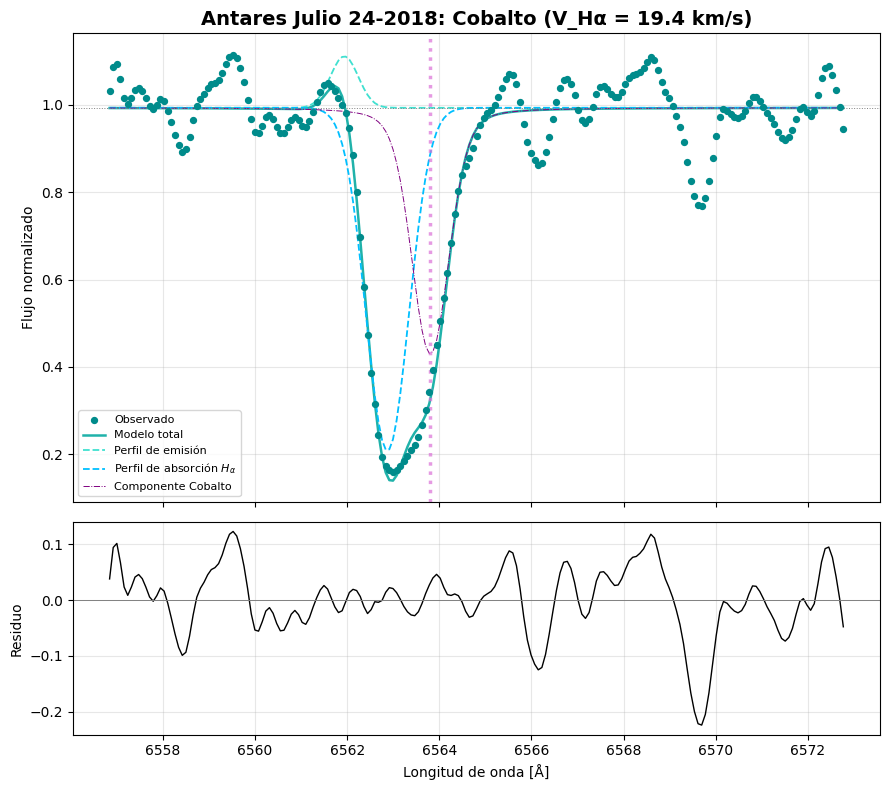

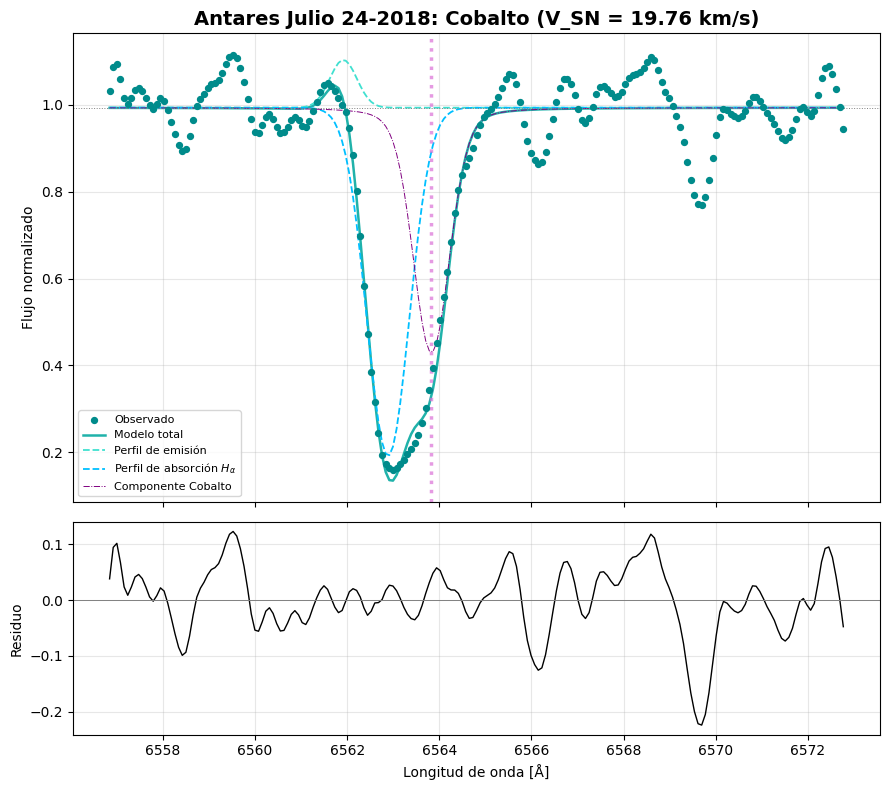

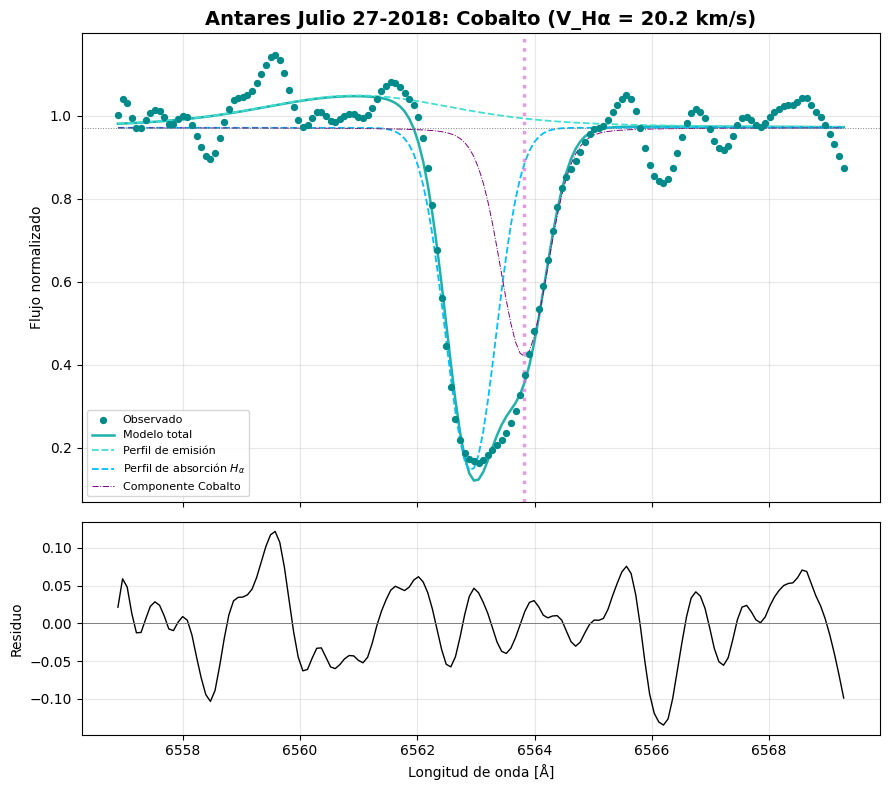

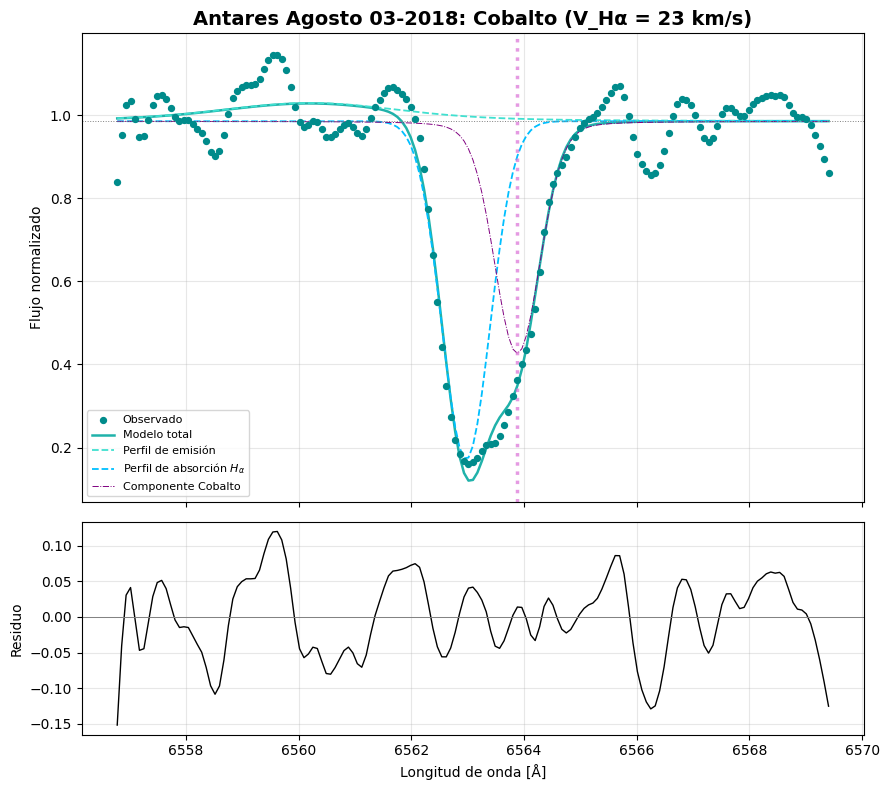

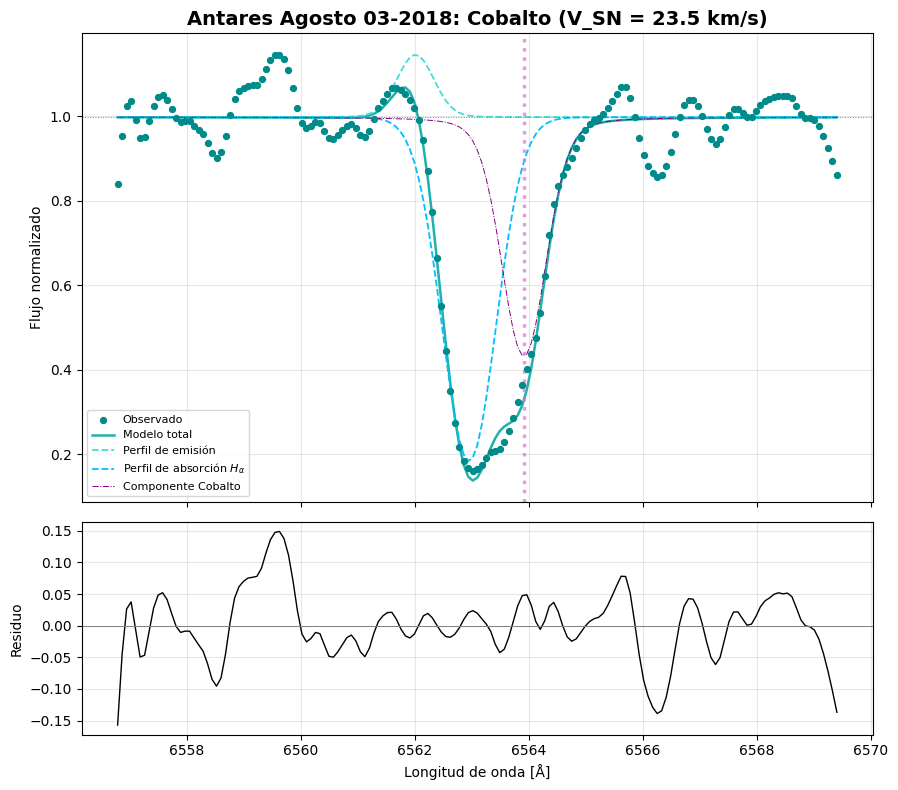

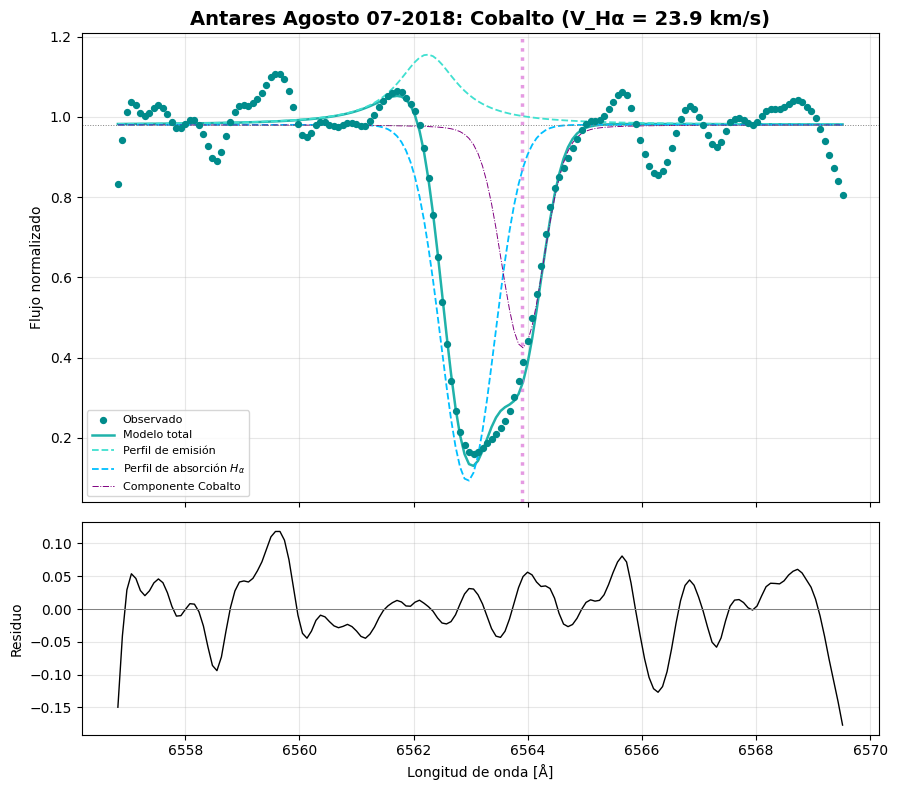

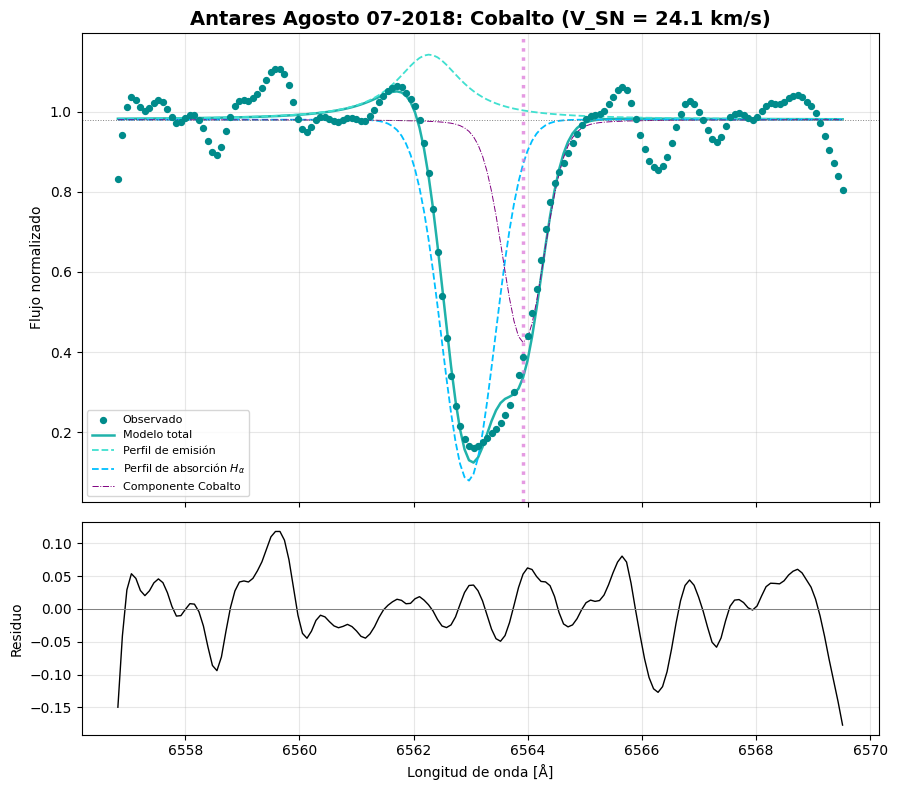

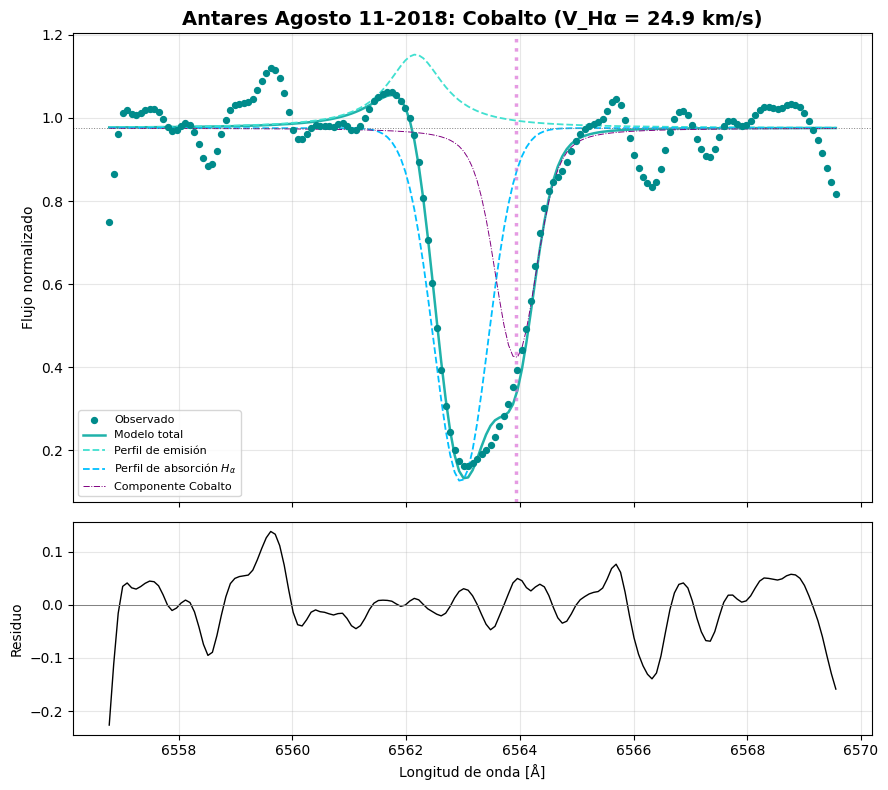

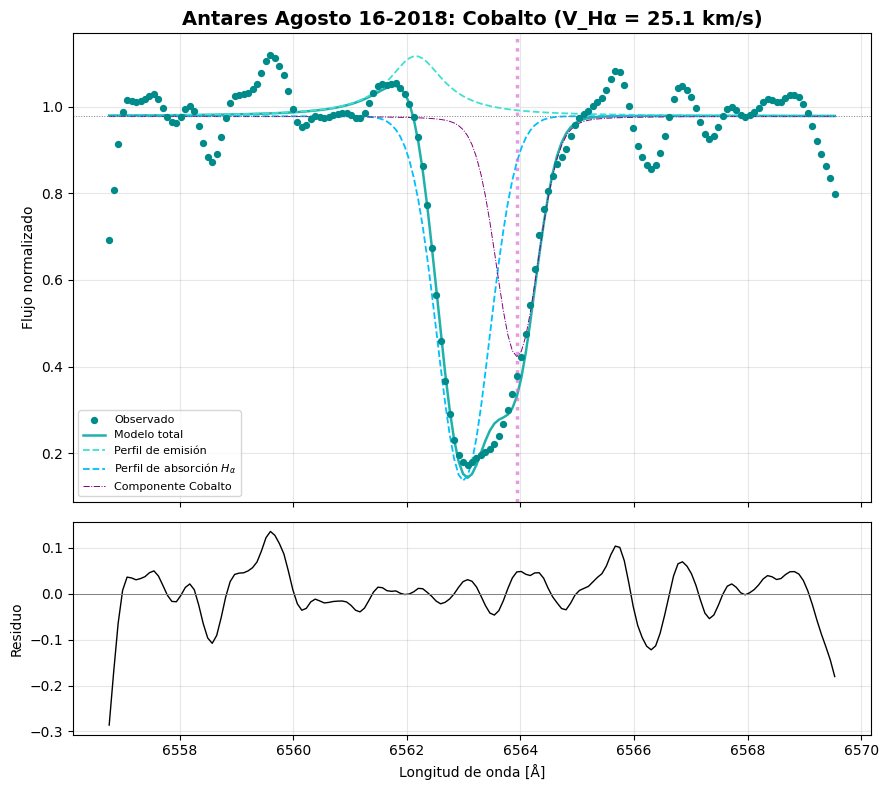

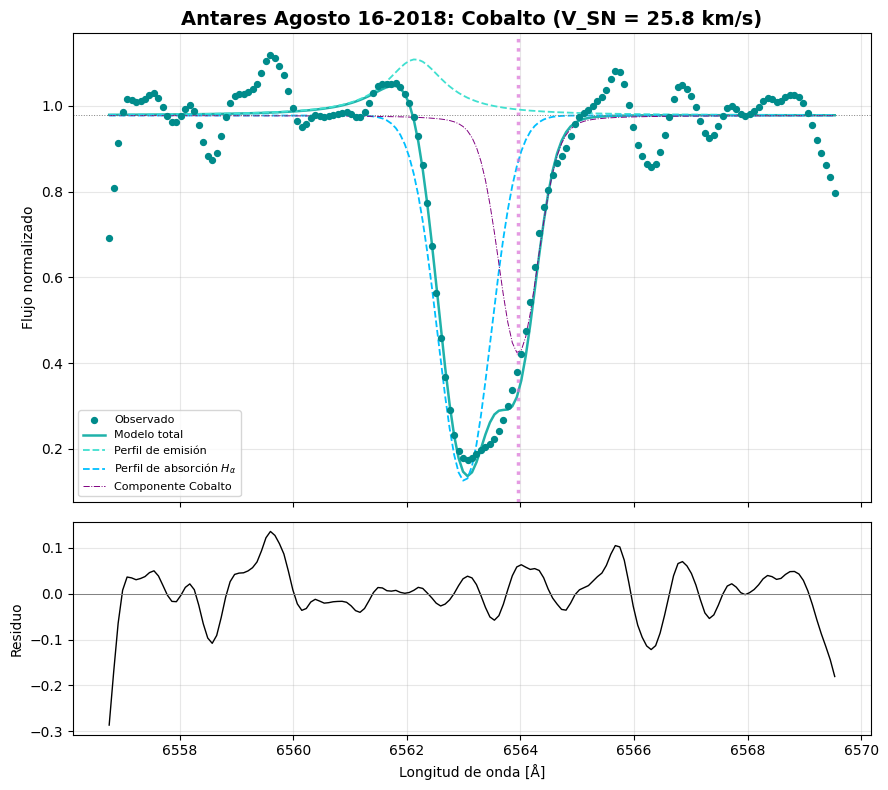

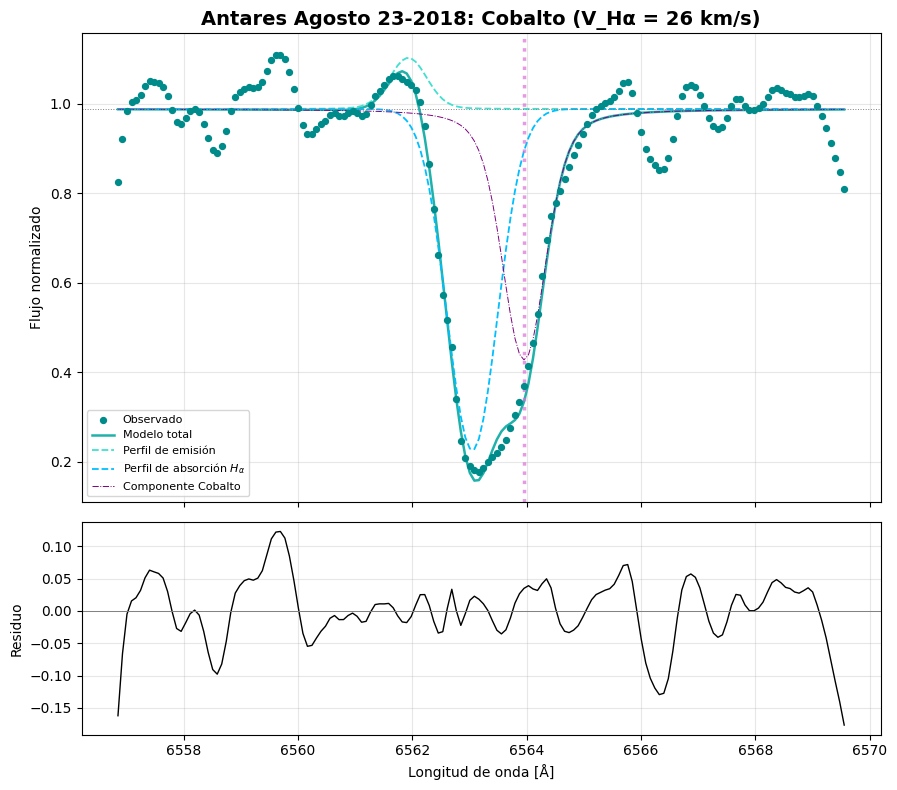

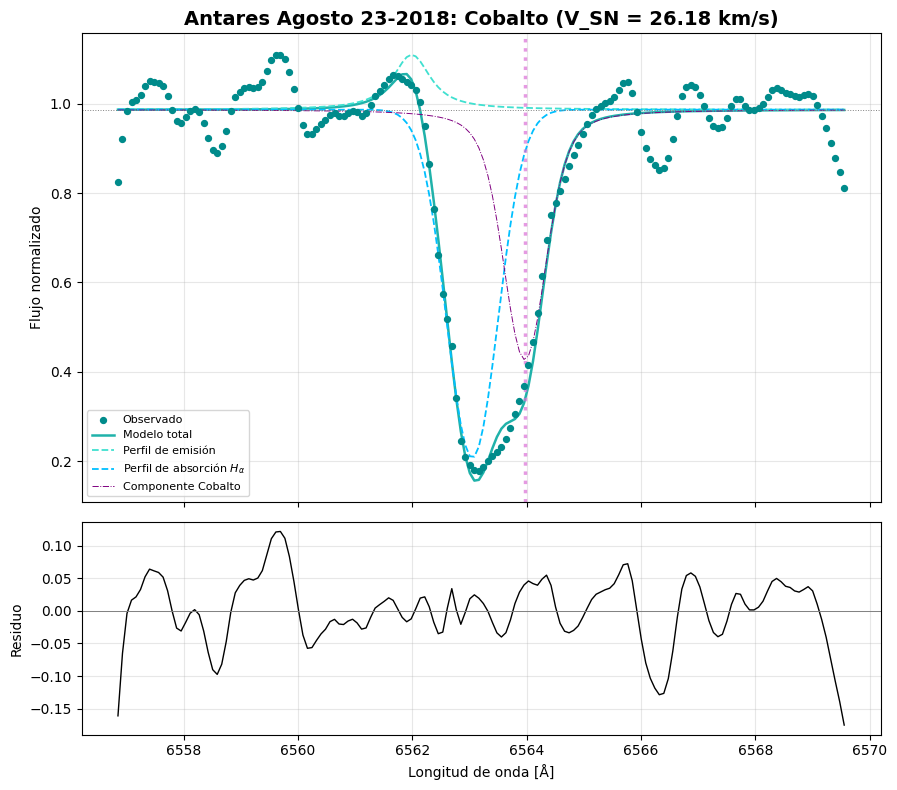

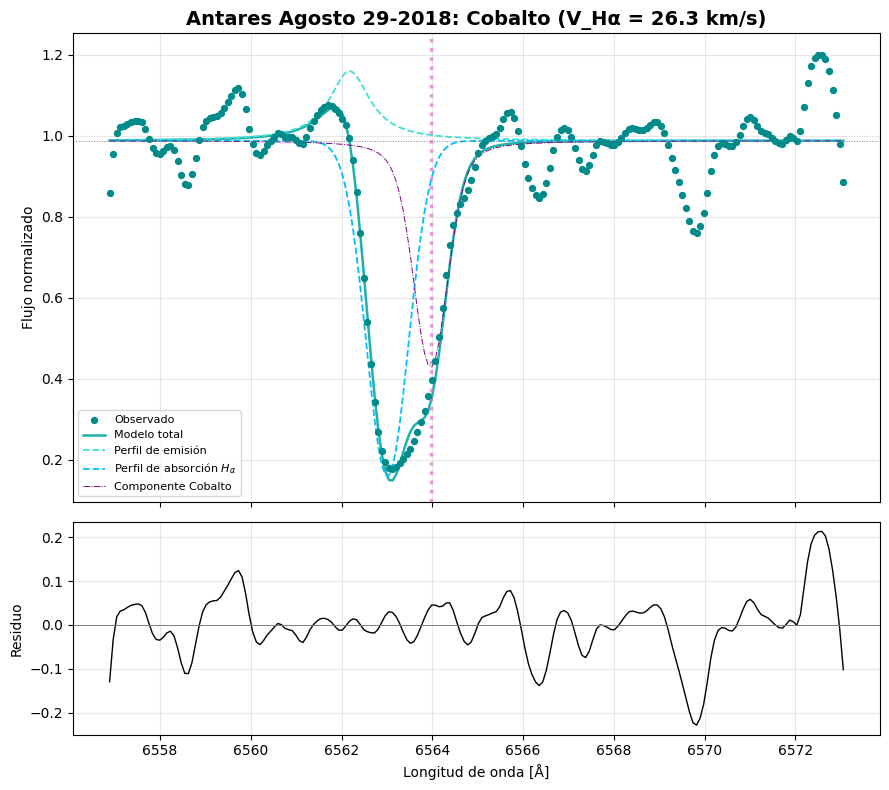

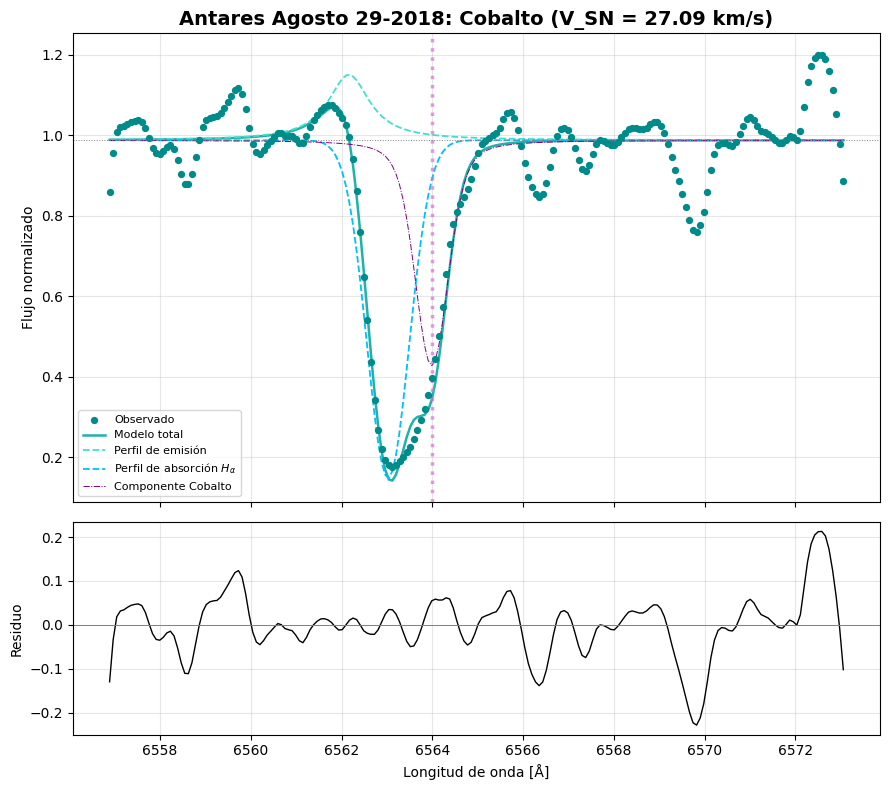

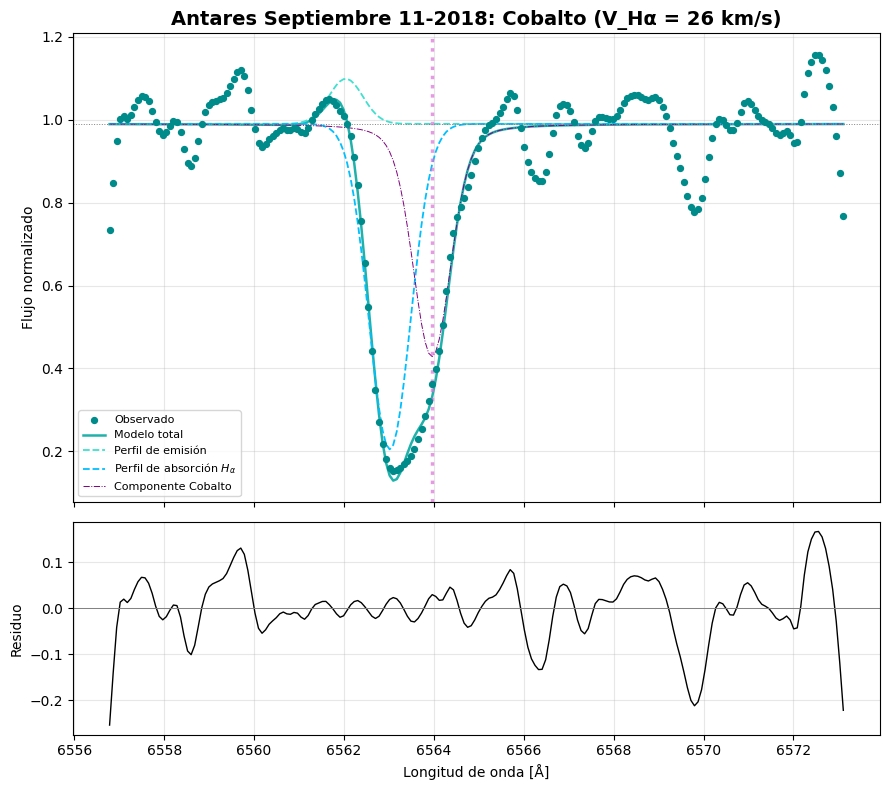

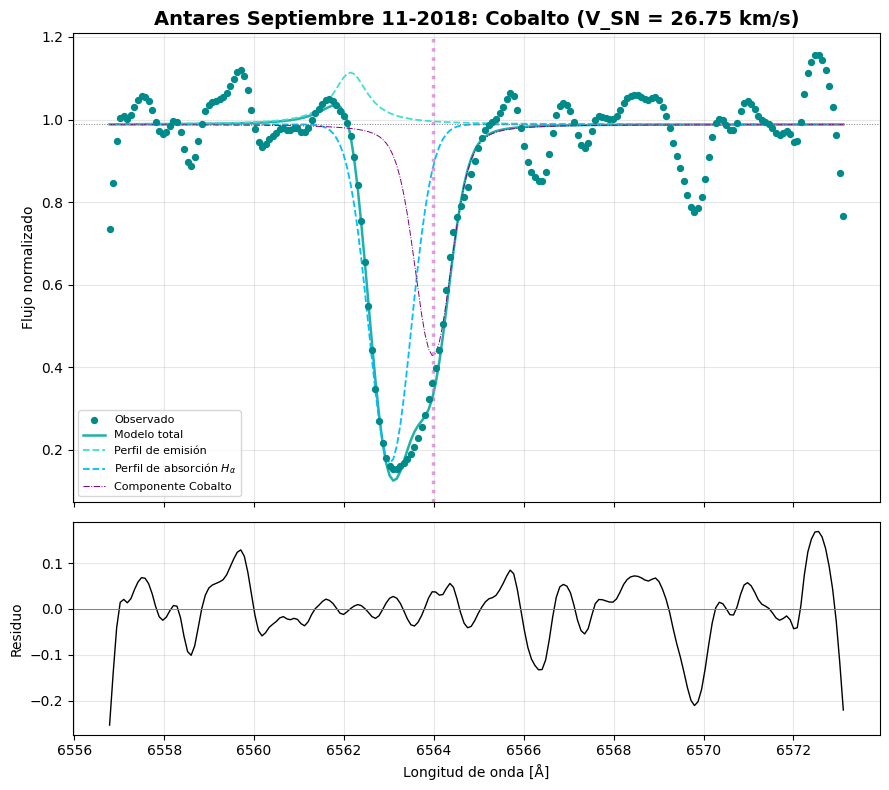

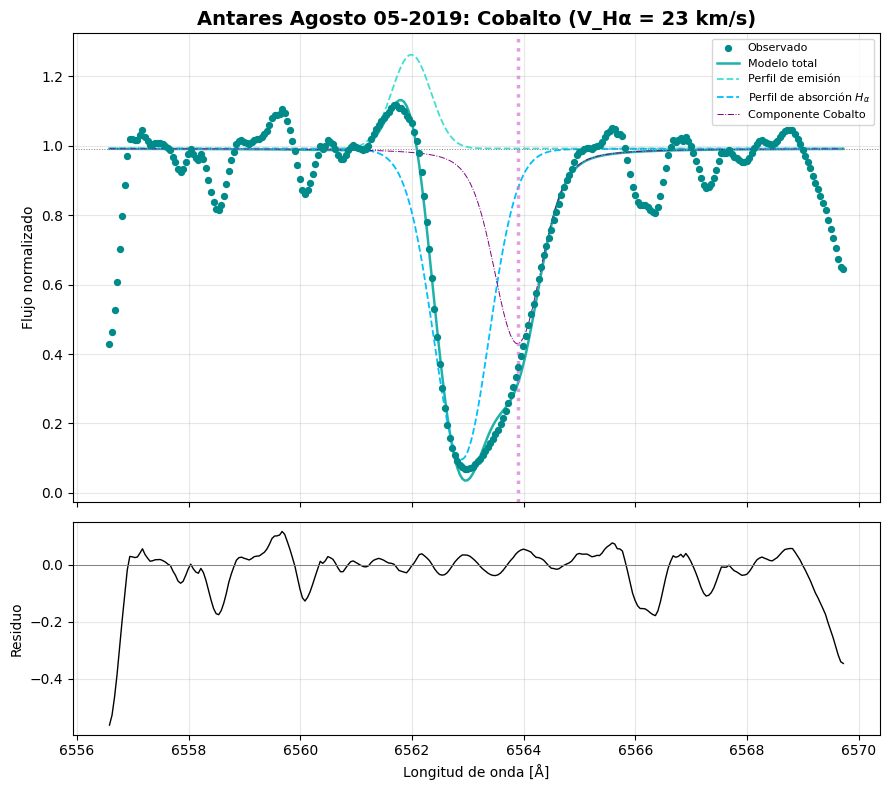

In [ ]:
centro_lab_cobalto = 6563.397

resultados = {}

for nombre, datos in espectros.items():
    meta = metadatos[nombre]
    fecha_str = meta["fecha"]
    

    
    fits_fecha = {}

    # Ajuste velocidad alredorde halpha

    if meta.get("Velocidad Hα") is not None:
        v_halpha = meta["Velocidad Hα"]
        err_halpha = meta.get("Incertidumbre v Hα", 3.0)
        
        lineas_halpha = [{
            "nombre": "Cobalto",
            "centro": centro_lab_cobalto,
            "velocidad": v_halpha,
            "incertidumbre_v": err_halpha,
            "prof_ref": (0.55, 0.63),
            "t_ref": (3500, 4250),
        }]
        
        fits_fecha["Hα"] = fit_y_decomposicion(
            datos, meta["centro_aprox"], "Longitud onda", "Flujo normalizado",
            lineas_metalicas=lineas_halpha, teff=3660
        )
        
        # Visualización
        visualizacion_con_metalica( fits_fecha["Hα"], lineas_halpha, f"{fecha_str}_Hα",
                                titulo=f"Antares {fecha_str}: Cobalto (V_Hα = {v_halpha} km/s)"
        )

    # Ajuste velocidad sector naranja (Si existe)

    if meta.get("Velocidad Sector naranja") is not None:
        v_ir = meta["Velocidad Sector naranja"]
        err_ir = meta.get("Incertidumbre v Sector naranja", 3.0)
        
        lineas_ir = [{
            "nombre": "Cobalto",
            "centro": centro_lab_cobalto,
            "velocidad": v_ir,
            "incertidumbre_v": err_ir,
            "prof_ref": (0.55, 0.63),
            "t_ref": (3500, 4250),
        }]
        
        fits_fecha["Sector naranja"] = fit_y_decomposicion(
            datos, meta["centro_aprox"], "Longitud onda", "Flujo normalizado",
            lineas_metalicas=lineas_ir, teff=3660
        )
        
        # Visualización individual
        visualizacion_con_metalica(
            fits_fecha["Sector naranja"], lineas_ir, f"{fecha_str}_Sector naranja",
            titulo=f"Antares {fecha_str}: Cobalto (V_SN = {v_ir} km/s)"
        )


    resultados[nombre] = fits_fecha



<h4 style="color: #e19edc;"> Mejor ajuste teniendo en cuenta la resolución de ESPARTACO I y Chi cuadrado </h4>

In [23]:
filas_chi2 = []

for nombre, fits_fecha in resultados.items():
    fecha_etiqueta = metadatos[nombre].get("fecha", nombre)
    
    # Chi del visible
    chi2_vis = fits_fecha["Hα"]["fit"].chisqr if "Hα" in fits_fecha else None
    
    # Chi del Sector naranja (si existe)
    chi2_ir = fits_fecha["Sector naranja"]["fit"].chisqr if "Sector naranja" in fits_fecha else "No existe"
    
    filas_chi2.append({
        "Fecha": fecha_etiqueta,
        "χ² (Hα)": round(chi2_vis, 4) if isinstance(chi2_vis, (int, float)) else chi2_vis,
        "χ² (SN)": round(chi2_ir, 4) if isinstance(chi2_ir, (int, float)) else chi2_ir,
        "Incertidumbre v Hα [km/s]": metadatos[nombre].get("Incertidumbre v Hα", "No existe"),
        "Incertidumbre v SN [km/s]": metadatos[nombre].get("Incertidumbre v Sector naranja", "No existe")
    })

tabla_chi2 = pd.DataFrame(filas_chi2)

display(tabla_chi2)

,Fecha,χ² (Hα),χ² (SN),Incertidumbre v Hα [km/s],Incertidumbre v SN [km/s]
0,Julio 24-2018,0.7557,0.763,0.7,0.05
1,Julio 27-2018,0.3863,No existe,0.8,No existe
2,Agosto 03-2018,0.4816,0.4508,0.9,0.03
3,Agosto 07-2018,0.4017,0.4101,0.5,0.04
4,Agosto 11-2018,0.4674,No existe,0.7,No existe
5,Agosto 16-2018,0.5274,0.5415,0.4,0.06
6,Agosto 23-2018,0.4150,0.4208,0.5,0.11
7,Agosto 29-2018,0.9725,0.985,0.4,0.15
8,Septiembre 11-2018,0.9368,0.9455,0.5,0.09
9,Agosto 05-2019,2.6178,No existe,0.5,No existe


In [24]:
tabla_chi2.to_excel(fr"Parámetros para análisis de Antares\Comparación chi cuadrado espectros del 2018 y 2019.xlsx", index=False)



<h5 style="color: #e19edc;"> Ambos espectros presentan una calidad de ajuste muy similar según el χ², pero el Sector Naranja proporciona velocidades con incertidumbres considerablemente menores.</h5>

In [25]:
h_alpha_natural = 6562.812
cobalto_natural = centro_lab_cobalto

resultados_perfiles_halpha_y_cobalto_r = []

for fecha, fits_fecha in resultados.items():

    fecha_etiqueta = metadatos[fecha].get("fecha", fecha)
    meta_fecha = metadatos[fecha]

    if "Velocidad Sector naranja" in meta_fecha:
        sector_usado = "Sector naranja"
    else:
        sector_usado = "Hα"

    if sector_usado not in fits_fecha:
        raise KeyError(
            f"La fecha '{fecha}' debería usar el sector '{sector_usado}' según metadatos, "
            f"pero no se encontró en fits_fecha. Claves disponibles: {list(fits_fecha.keys())}"
        )

    mejor_clave = sector_usado
    res = fits_fecha[mejor_clave]

    # Extraer parámetros
    p = res["fit"].params
    comps = res["comps"]
    longitud_onda = res["longitud_onda"]
    continuo = comps["cont_"]

    # 1. PERFIL DE EMISIÓN AZUL
    c_em = p["em_azul_center"].value
    fwhm_em = p["em_azul_fwhm"].value
    amp_em = p["em_azul_height"].value

    z_em = (c_em - h_alpha_natural) / h_alpha_natural
    v_em = z_em * c_kms_s

    perfil_em_puro = comps["em_azul_"]
    ew_em = np.trapezoid(perfil_em_puro / continuo, longitud_onda)

    resultados_perfiles_halpha_y_cobalto_r.append({
        "Época": fecha_etiqueta,
        "Ajuste Seleccionado": mejor_clave,
        "Componente": "Emisión Azul Hα",
        "Centro [Å]": round(c_em, 3),
        "z": round(z_em, 6),
        "Velocidad [km/s]": round(v_em, 4),
        "Profundidad / Altura": round(amp_em, 4),
        "FWHM [Å]": round(fwhm_em, 3),
        "EW [Å]": round(ew_em, 4)
    })

    # 2. PERFIL DE ABSORCIÓN H_ALPHA
    c_abs = p["valle_abs_center"].value
    fwhm_abs = p["valle_abs_fwhm"].value
    prof_abs = abs(p["valle_abs_height"].value)

    z_abs = (c_abs - h_alpha_natural) / h_alpha_natural
    v_abs = z_abs * c_kms_s

    perfil_abs_puro = comps["valle_abs_"]
    ew_abs = np.trapezoid(abs(perfil_abs_puro) / continuo, longitud_onda)

    resultados_perfiles_halpha_y_cobalto_r.append({
        "Época": fecha_etiqueta,
        "Ajuste Seleccionado": mejor_clave,
        "Componente": "Absorción Hα",
        "Centro [Å]": round(c_abs, 3),
        "z": round(z_abs, 6),
        "Velocidad [km/s]": round(v_abs, 4),
        "Profundidad / Altura": round(prof_abs, 4),
        "FWHM [Å]": round(fwhm_abs, 3),
        "EW [Å]": round(ew_abs, 4)
    })

    # 3. LÍNEA DE COBALTO
    c_co = p["Cobalto_center"].value
    fwhm_co = p["Cobalto_fwhm"].value
    prof_co = abs(p["Cobalto_height"].value)

    z_co = (c_co - cobalto_natural) / cobalto_natural
    v_co = z_co * c_kms_s

    perfil_co_puro = comps["Cobalto_"]
    ew_co = np.trapezoid(abs(perfil_co_puro) / continuo, longitud_onda)

    resultados_perfiles_halpha_y_cobalto_r.append({
        "Época": fecha_etiqueta,
        "Ajuste Seleccionado": mejor_clave,
        "Componente": "Absorción Cobalto",
        "Centro [Å]": round(c_co, 3),
        "z": round(z_co, 6),
        "Velocidad [km/s]": round(v_co, 4),
        "Profundidad / Altura": round(prof_co, 4),
        "FWHM [Å]": round(fwhm_co, 3),
        "EW [Å]": round(ew_co, 4)
    })

tabla_resultados_r = pd.DataFrame(resultados_perfiles_halpha_y_cobalto_r)
display(tabla_resultados_r)

,Época,Ajuste Seleccionado,Componente,Centro [Å],z,Velocidad [km/s],Profundidad / Altura,FWHM [Å],EW [Å]
0,Julio 24-2018,Sector naranja,Emisión Azul Hα,6561.916,-0.000137,-40.9246,0.1098,0.696,0.0819
1,Julio 24-2018,Sector naranja,Absorción Hα,6562.887,0.000011,3.4391,0.8004,1.086,0.9325
2,Julio 24-2018,Sector naranja,Absorción Cobalto,6563.829,0.000066,19.7100,0.5629,0.943,0.6163
3,Julio 27-2018,Hα,Emisión Azul Hα,6560.974,-0.000280,-83.9625,0.0777,4.044,0.3686
4,Julio 27-2018,Hα,Absorción Hα,6562.914,0.000015,4.6448,0.8252,1.012,0.9162
5,Julio 27-2018,Hα,Absorción Cobalto,6563.822,0.000065,19.4000,0.5504,0.959,0.6089
6,Agosto 03-2018,Sector naranja,Emisión Azul Hα,6562.008,-0.000122,-36.7212,0.1475,0.766,0.1235
7,Agosto 03-2018,Sector naranja,Absorción Hα,6562.948,0.000021,6.2216,0.8140,1.118,0.9757
8,Agosto 03-2018,Sector naranja,Absorción Cobalto,6563.911,0.000078,23.4701,0.5656,0.927,0.5998
9,Agosto 07-2018,Sector naranja,Emisión Azul Hα,6562.272,-0.000082,-24.6879,0.1623,1.383,0.3288


In [26]:
tabla_resultados_r.to_excel(fr"Parámetros para análisis de Antares\Resultados perfiles halpha 2018 y 2019 priorizando el sector naranja.xlsx", index=False)